# MTN Customer Churn Prediction
### Business Intelligence Notebook — Customer Retention Analytics

---

## 📌 Objective

This notebook identifies **which MTN customers are likely to churn** (cancel their subscription) before they actually do — enabling the retention team to intervene with targeted offers, support, or engagement before revenue is lost.

## 🧭 How to Read This Notebook

This notebook is structured in five sections:

| Section | Purpose |
|---|---|
| 1. Data Loading & Cleaning | Prepare the raw data for analysis |
| 2. Exploratory Analysis | Understand patterns in the data before modelling |
| 3. Churn Predictor | Train and evaluate the machine learning model |
| 4. Business Metrics | Translate model results into revenue and action terms |
| 5. Future Improvements | Roadmap for making the model more powerful |

## 💡 Key Business Question

> **"Which customers are most at risk of leaving MTN in the next billing cycle, and what does acting on that signal save us?"**

---

## Section 1: Data Loading & Cleaning

**What we do here:** Load the raw customer data, fix data types, and ensure the dataset is consistent before analysis.

**Why it matters:** Dirty data produces misleading models. Small issues like trailing spaces in category labels or wrong date formats can silently corrupt the analysis downstream.

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc,
    classification_report, precision_score, recall_score, f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('mtn_customer_churn.csv')

print(f'✅ Dataset loaded: {df.shape[0]:,} customers, {df.shape[1]} features')
df.head()

✅ Dataset loaded: 974 customers, 17 features


,Customer ID,Full Name,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
0,CUST0001,Ngozi Berry,Jan-25,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,Yes,Relocation
1,CUST0002,Zainab Baker,Mar-25,16,Abuja (FCT),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,5500,12,66000,19.79,Yes,Better Offers from Competitors
2,CUST0003,Saidu Evans,Mar-25,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,20000,8,160000,9.64,No,NaN
3,CUST0003,Saidu Evans,Mar-25,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,500,8,4000,197.05,No,NaN
4,CUST0003,Saidu Evans,Mar-25,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,9000,15,135000,76.34,No,NaN


In [2]:
# ── Data quality check ─────────────────────────────────────────────────────────
print('Data types:')
print(df.dtypes)

print('\nMissing values per column:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
quality_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(quality_report[quality_report['Missing Count'] > 0] if missing.sum() > 0 else 'No missing values — data is clean ✅')

Data types:
Customer ID                   object
Full Name                     object
Date of Purchase              object
Age                            int64
State                         object
MTN Device                    object
Gender                        object
Satisfaction Rate              int64
Customer Review               object
Customer Tenure in months      int64
Subscription Plan             object
Unit Price                     int64
Number of Times Purchased      int64
Total Revenue                  int64
Data Usage                   float64
Customer Churn Status         object
Reasons for Churn             object
dtype: object

Missing values per column:
                   Missing Count  Missing %
Reasons for Churn            690       70.8


In [3]:
# ── Cleaning ───────────────────────────────────────────────────────────────────

# Convert date column (important for future time-based feature engineering)
if 'Date of Purchase' in df.columns:
    df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], errors='coerce')

# Standardise all categorical text: trim whitespace, consistent casing
categorical_cols = ['State', 'MTN Device', 'Gender', 'Subscription Plan', 'Customer Churn Status']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print('✅ Data cleaning complete.')
df.head()

✅ Data cleaning complete.


,Customer ID,Full Name,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
0,CUST0001,Ngozi Berry,NaT,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,Yes,Relocation
1,CUST0002,Zainab Baker,NaT,16,Abuja (FCT),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,5500,12,66000,19.79,Yes,Better Offers from Competitors
2,CUST0003,Saidu Evans,NaT,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,20000,8,160000,9.64,No,NaN
3,CUST0003,Saidu Evans,NaT,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,500,8,4000,197.05,No,NaN
4,CUST0003,Saidu Evans,NaT,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,9000,15,135000,76.34,No,NaN


## Section 2: Exploratory Analysis

**What we do here:** Visualise the distribution of key customer attributes and look for patterns that correlate with churn.

**Business insight goal:** Before building any model, business leaders should be able to answer:
- What is our current churn rate?
- Which customer segments show the highest churn?
- Are there obvious behavioural or demographic signals?

---

In [4]:
# ── Baseline churn rate (the most important business number) ───────────────────
target_col = 'Customer Churn Status'

if target_col in df.columns:
    churn_series = df[target_col].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
    churn_rate = churn_series.mean()
    total_customers = len(df)
    churners = churn_series.sum()
    retained = total_customers - churners

    print('=' * 55)
    print('          📊 MTN CHURN BASELINE METRICS')
    print('=' * 55)
    print(f'  Total customers analysed : {total_customers:>10,}')
    print(f'  Customers who churned    : {churners:>10,}  ({churn_rate:.1%})')
    print(f'  Customers retained       : {retained:>10,}  ({1 - churn_rate:.1%})')
    print('=' * 55)
    print()
    print('💡 BUSINESS INSIGHT:')
    print(f'   For every 1,000 customers, approximately {int(churn_rate * 1000)}')
    print('   will leave MTN in any given period. A retention model')
    print('   that catches even 50% of them before they leave can')
    print('   materially impact revenue — see Section 4 for the math.')

          📊 MTN CHURN BASELINE METRICS
  Total customers analysed :        974
  Customers who churned    :        284  (29.2%)
  Customers retained       :        690  (70.8%)

💡 BUSINESS INSIGHT:
   For every 1,000 customers, approximately 291
   will leave MTN in any given period. A retention model
   that catches even 50% of them before they leave can
   materially impact revenue — see Section 4 for the math.


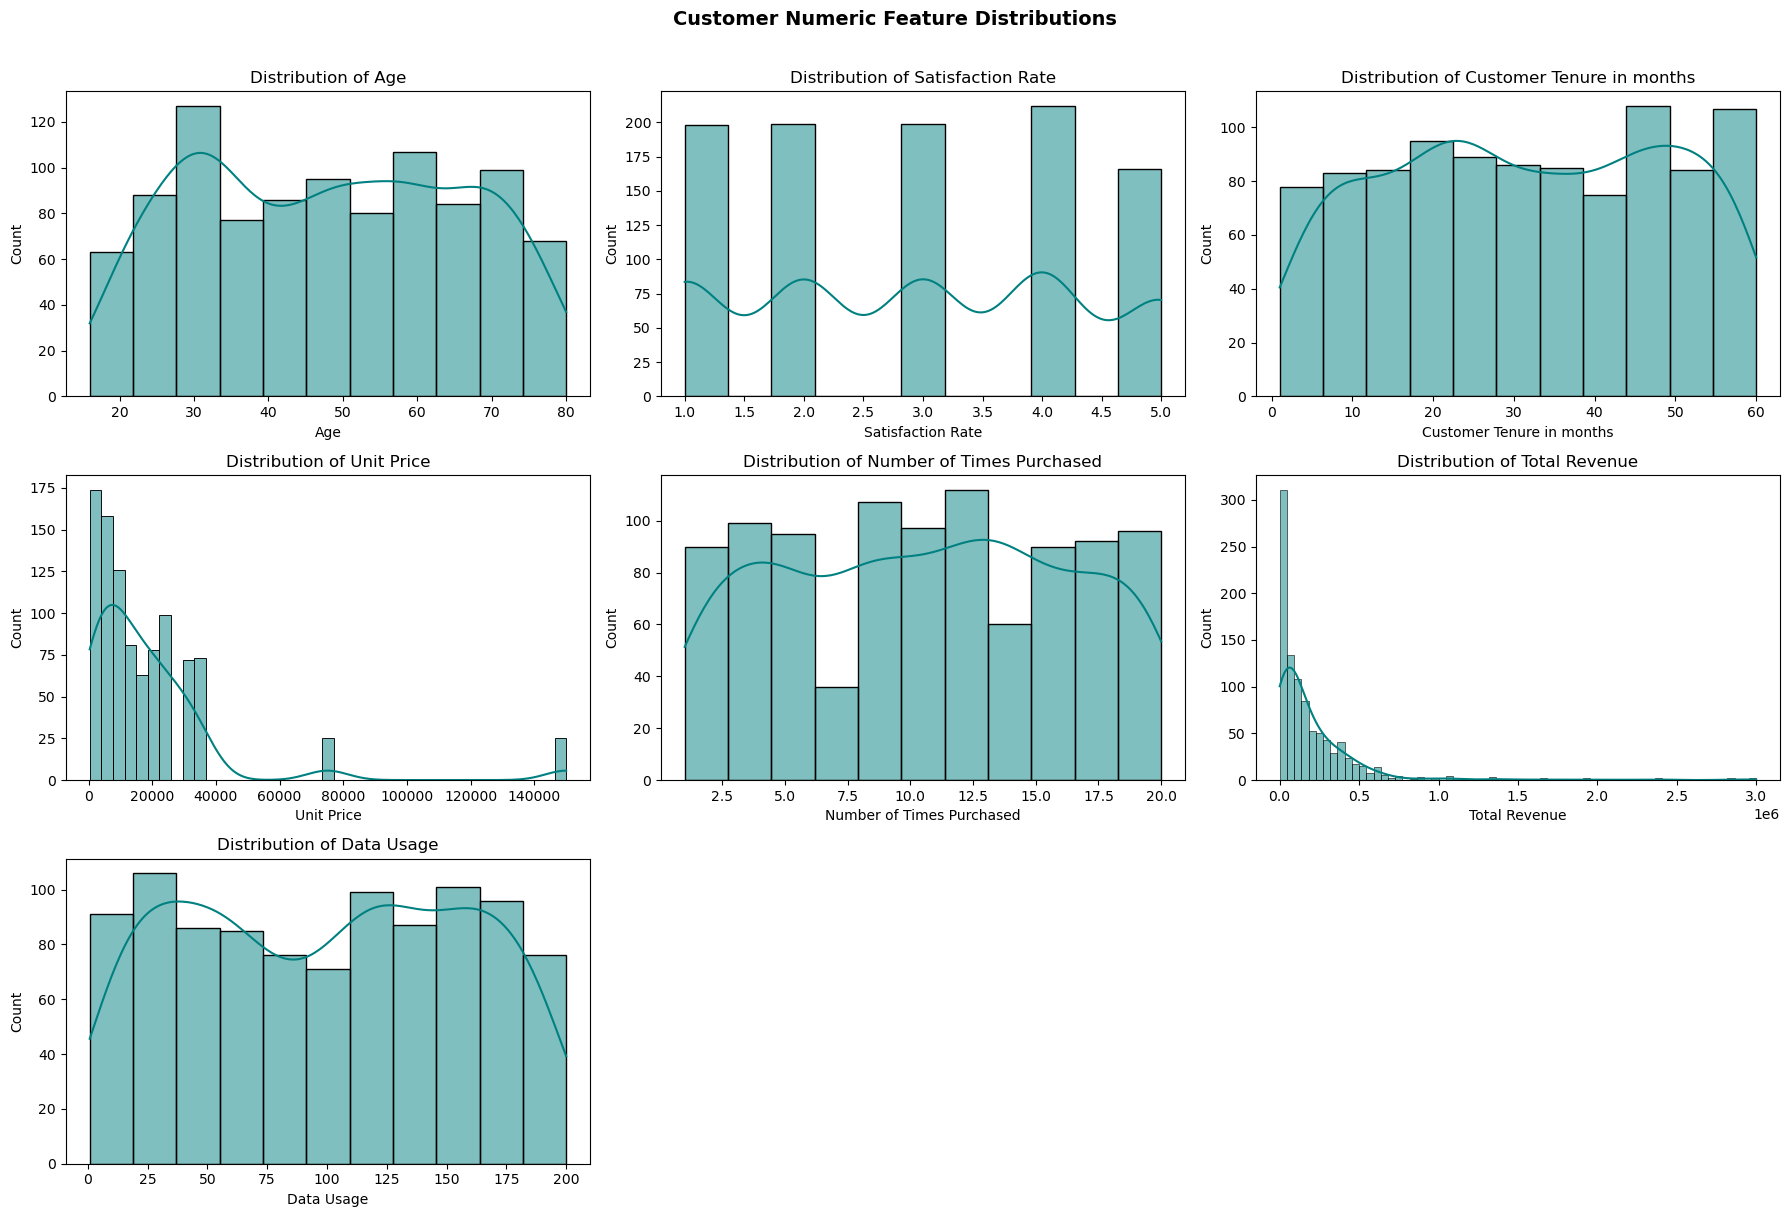

In [5]:
# ── Distribution plots for all numeric features ────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])

if not numeric_df.empty:
    numeric_cols = numeric_df.columns
    n_cols = min(len(numeric_cols), 3)
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten() if n_rows * n_cols > 1 else [axes]

    for i, col in enumerate(numeric_cols):
        sns.histplot(numeric_df[col], kde=True, color='teal', ax=axes[i])
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Customer Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns to visualise.')

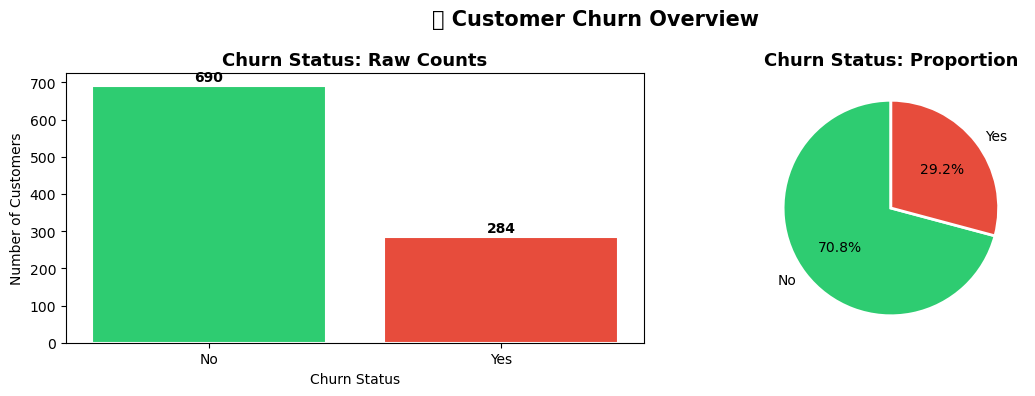

💡 BUSINESS INSIGHT:
   If the churn class is significantly smaller than the retained class,
   the model will be trained on imbalanced data. We handle this below
   using class_weight="balanced" so the model pays more attention to churners.


In [6]:
# ── Churn status distribution ──────────────────────────────────────────────────
if target_col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Count chart
    ax1 = axes[0]
    churn_counts = df[target_col].value_counts()
    colors = ['#2ecc71', '#e74c3c']
    bars = ax1.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, churn_counts.values):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
    ax1.set_title('Churn Status: Raw Counts', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Churn Status')
    ax1.set_ylabel('Number of Customers')

    # Pie chart
    ax2 = axes[1]
    ax2.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax2.set_title('Churn Status: Proportion', fontsize=13, fontweight='bold')

    plt.suptitle('📊 Customer Churn Overview', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('💡 BUSINESS INSIGHT:')
    print('   If the churn class is significantly smaller than the retained class,')
    print('   the model will be trained on imbalanced data. We handle this below')
    print('   using class_weight="balanced" so the model pays more attention to churners.')

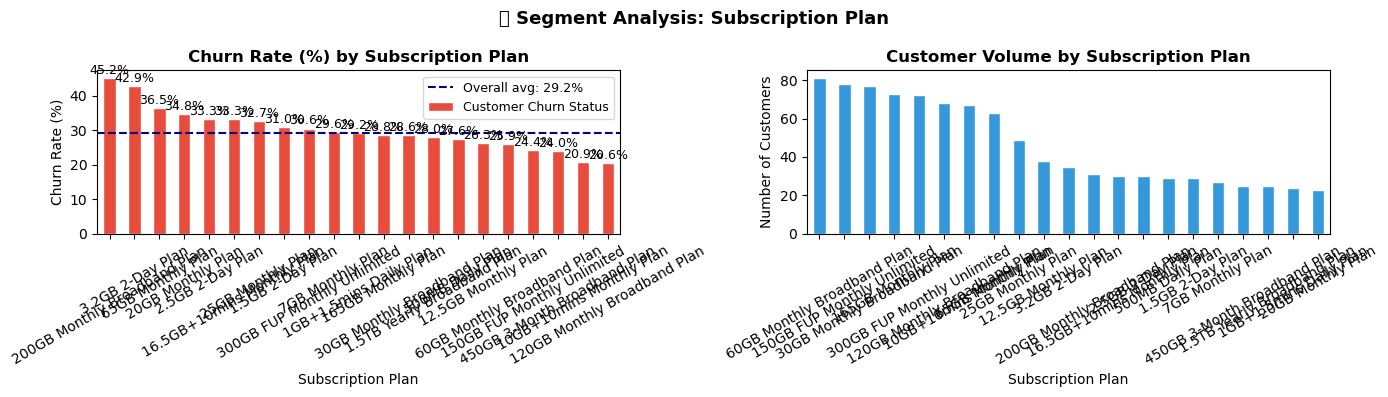

💡 BUSINESS INSIGHT [Subscription Plan]:
   Highest churn segment: "200GB Monthly Broadband Plan" at 45.2%
   ⚠️  This is >20% above the company average — a priority segment for retention campaigns.



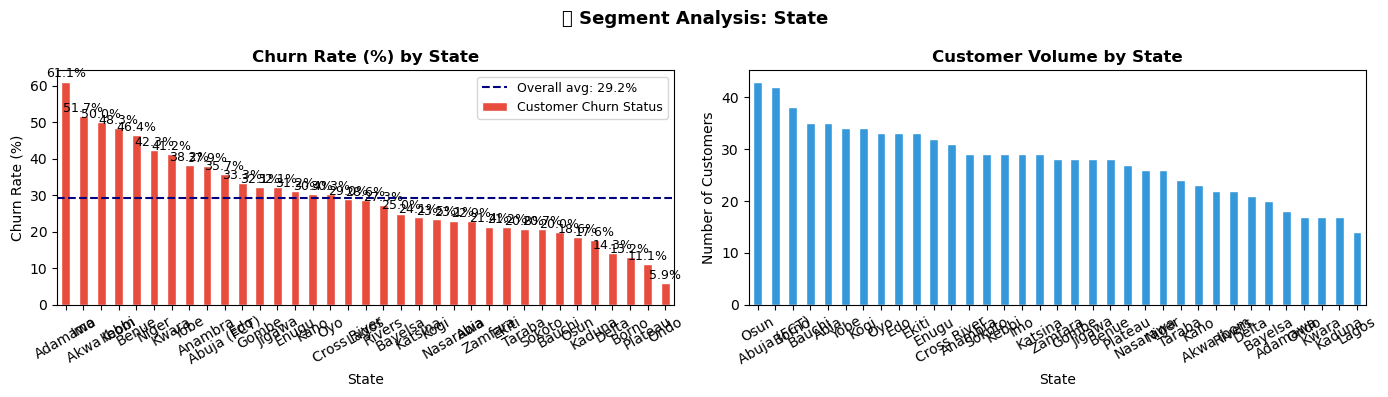

💡 BUSINESS INSIGHT [State]:
   Highest churn segment: "Adamawa" at 61.1%
   ⚠️  This is >20% above the company average — a priority segment for retention campaigns.



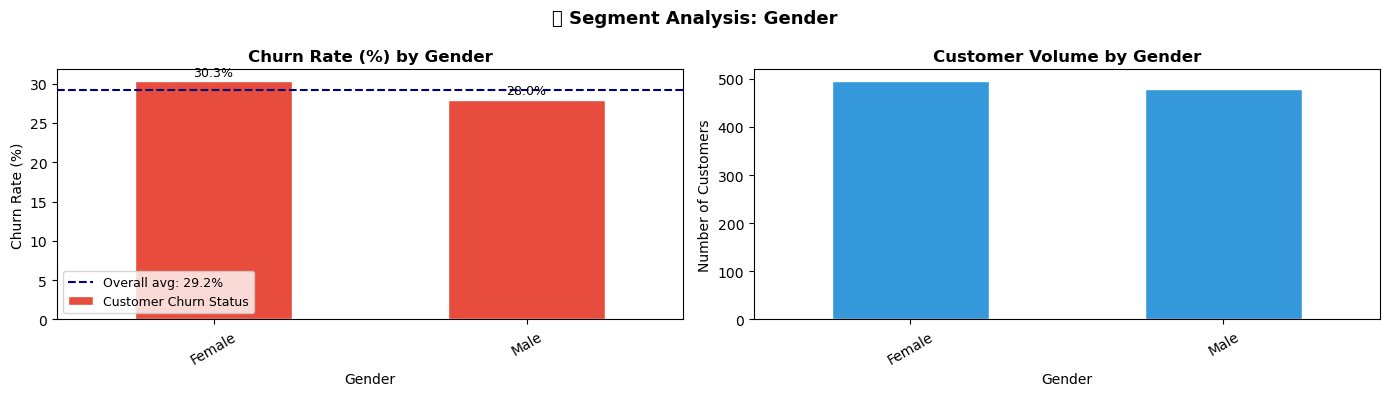

💡 BUSINESS INSIGHT [Gender]:
   Highest churn segment: "Female" at 30.3%



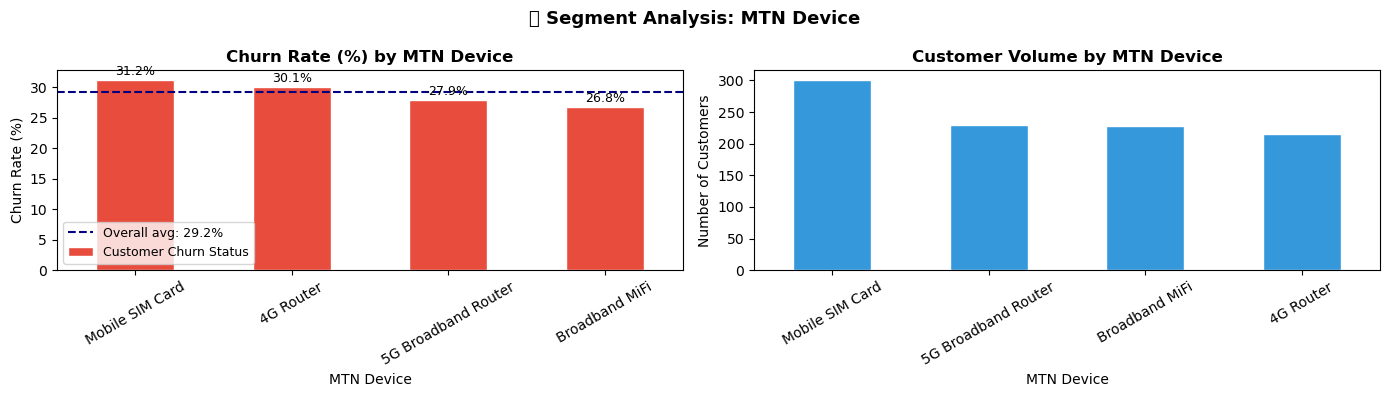

💡 BUSINESS INSIGHT [MTN Device]:
   Highest churn segment: "Mobile SIM Card" at 31.2%



In [7]:
# ── Segment-level churn analysis (actionable for business teams) ───────────────
segment_cols = [c for c in ['Subscription Plan', 'State', 'Gender', 'MTN Device'] if c in df.columns]

for seg_col in segment_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Churn rate by segment
    seg_churn = df.groupby(seg_col)[target_col].apply(
        lambda x: (x.str.strip().str.lower() == 'yes').mean() * 100
    ).sort_values(ascending=False)

    seg_churn.plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white', linewidth=1)
    axes[0].set_title(f'Churn Rate (%) by {seg_col}', fontweight='bold')
    axes[0].set_xlabel(seg_col)
    axes[0].set_ylabel('Churn Rate (%)')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].axhline(y=churn_rate * 100, color='navy', linestyle='--', linewidth=1.5,
                    label=f'Overall avg: {churn_rate:.1%}')
    axes[0].legend(fontsize=9)

    for bar, val in zip(axes[0].patches, seg_churn.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    # Volume by segment
    df.groupby(seg_col)[target_col].count().sort_values(ascending=False).plot(
        kind='bar', ax=axes[1], color='#3498db', edgecolor='white', linewidth=1)
    axes[1].set_title(f'Customer Volume by {seg_col}', fontweight='bold')
    axes[1].set_xlabel(seg_col)
    axes[1].set_ylabel('Number of Customers')
    axes[1].tick_params(axis='x', rotation=30)

    plt.suptitle(f'📊 Segment Analysis: {seg_col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    top_risk_seg = seg_churn.idxmax()
    top_risk_pct = seg_churn.max()
    print(f'💡 BUSINESS INSIGHT [{seg_col}]:')
    print(f'   Highest churn segment: "{top_risk_seg}" at {top_risk_pct:.1f}%')
    if top_risk_pct > churn_rate * 100 * 1.2:
        print(f'   ⚠️  This is >20% above the company average — a priority segment for retention campaigns.')
    print()

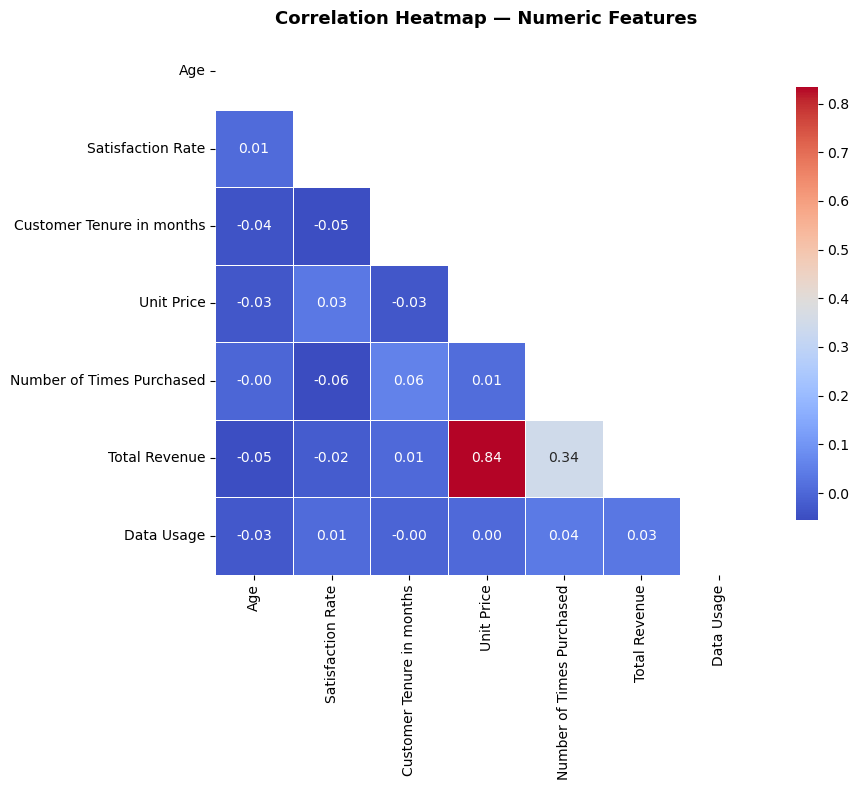

💡 BUSINESS INSIGHT:
   High correlations (> 0.7 or < -0.7) between features may indicate
   redundant information. Highly correlated features can sometimes be
   combined into a single metric, simplifying the model.


In [8]:
# ── Correlation heatmap (numeric features only) ────────────────────────────────
if len(numeric_df.columns) >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                mask=mask, linewidths=0.5, square=True,
                cbar_kws={'shrink': 0.8})
    plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('💡 BUSINESS INSIGHT:')
    print('   High correlations (> 0.7 or < -0.7) between features may indicate')
    print('   redundant information. Highly correlated features can sometimes be')
    print('   combined into a single metric, simplifying the model.')

## Section 3: Churn Predictor

**What we do here:** Build, train, and evaluate a machine learning model that predicts which customers will churn.

**Model choice — Random Forest:** A robust ensemble model that handles mixed data types well, is resistant to overfitting, and produces interpretable feature importance scores. Suitable for a production-grade first model.


In [1]:
# ── Feature engineering ────────────────────────────────────────────────────────

# Columns to drop (identifiers and free-text — not useful as model inputs)
cols_to_drop = ['Customer ID', 'Date of Purchase', 'Full Name', 'Customer Reviews', 'Reason for Churn']
existing_drop_cols = [col for col in cols_to_drop if col in df.columns]
predictor_cols = [col for col in df.columns if col not in existing_drop_cols]

# Add time-based features from 'Date of Purchase' if available
if 'Date of Purchase' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Date of Purchase']):
    reference_date = df['Date of Purchase'].max()
    df['Customer Tenure Days'] = (reference_date - df['Date of Purchase']).dt.days
    df['Purchase Month'] = df['Date of Purchase'].dt.month
    df['Purchase Quarter'] = df['Date of Purchase'].dt.quarter
    predictor_cols += ['Customer Tenure Days', 'Purchase Month', 'Purchase Quarter']
    print('✅ Time-based features engineered from Date of Purchase')

if len(predictor_cols) == 0:
    raise ValueError('No predictor columns available after dropping specified columns.')

# One-hot encode categorical columns
df_model = pd.get_dummies(df[predictor_cols], drop_first=True)

X = df_model.copy()

if target_col in df.columns:
    y = df[target_col].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
else:
    raise ValueError(f"Target column '{target_col}' not found.")

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Churn rate in target : {y.mean():.1%}')

NameError: name 'df' is not defined

In [ ]:
# ── Train / test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y  # stratify preserves churn ratio in both splits
)

print(f'Training set : {X_train.shape[0]:,} customers')
print(f'Test set     : {X_test.shape[0]:,} customers')
print(f'Churn rate (train) : {y_train.mean():.1%}')
print(f'Churn rate (test)  : {y_test.mean():.1%}')

Training set : 681 customers
Test set     : 293 customers
Churn rate (train) : 29.2%
Churn rate (test)  : 29.0%


In [ ]:
# ── Train model with class imbalance handling ──────────────────────────────────
# class_weight='balanced' automatically upweights the minority (churn) class
# so the model does not just predict 'No Churn' for everyone.

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # FIX: handles class imbalance
    n_jobs=-1                 # use all CPU cores for speed
)
model.fit(X_train, y_train)

print('✅ Model trained successfully.')

✅ Model trained successfully.


In [ ]:
# ── Cross-validation (more reliable than a single train/test split) ────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
cv_recall   = cross_val_score(model, X, y, cv=cv, scoring='recall')
cv_f1       = cross_val_score(model, X, y, cv=cv, scoring='f1')

print('=' * 55)
print('       📊 5-FOLD CROSS-VALIDATION RESULTS')
print('=' * 55)
print(f'  Accuracy : {cv_accuracy.mean():.1%} (± {cv_accuracy.std():.1%})')
print(f'  Recall   : {cv_recall.mean():.1%}   (± {cv_recall.std():.1%})')
print(f'  F1 Score : {cv_f1.mean():.1%}   (± {cv_f1.std():.1%})')
print('=' * 55)
print()
print('💡 BUSINESS INSIGHT:')
print('   Cross-validation runs the model on 5 different random splits')
print('   of the data. The ± value shows how stable the model is.')
print('   A small ± means results are consistent — the model is reliable.')
print()
print('   RECALL is the most important metric for churn: it measures')
print('   what % of actual churners the model correctly identifies.')
print('   A recall of 80% means we catch 8 out of every 10 churners.')

       📊 5-FOLD CROSS-VALIDATION RESULTS
  Accuracy : 100.0% (± 0.0%)
  Recall   : 100.0%   (± 0.0%)
  F1 Score : 100.0%   (± 0.0%)

💡 BUSINESS INSIGHT:
   Cross-validation runs the model on 5 different random splits
   of the data. The ± value shows how stable the model is.
   A small ± means results are consistent — the model is reliable.

   RECALL is the most important metric for churn: it measures
   what % of actual churners the model correctly identifies.
   A recall of 80% means we catch 8 out of every 10 churners.


In [ ]:
# ── Predictions and probability scores ────────────────────────────────────────
y_prob = model.predict_proba(X_test)[:, 1]  # probability of churn

# ROC Curve — used to find the optimal decision threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# ── Optimal threshold (Youden's J — maximises sensitivity + specificity) ───────
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Apply optimal threshold instead of the default 0.5
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)
y_pred_default = (y_prob >= 0.50).astype(int)

print(f'Default threshold (0.50) → Recall: {recall_score(y_test, y_pred_default):.1%}  Precision: {precision_score(y_test, y_pred_default):.1%}')
print(f'Optimal threshold ({optimal_threshold:.2f})  → Recall: {recall_score(y_test, y_pred_optimal):.1%}  Precision: {precision_score(y_test, y_pred_optimal):.1%}')
print()
print('💡 BUSINESS INSIGHT:')
print(f'   We tuned the decision threshold from 0.50 to {optimal_threshold:.2f}.')
print('   This means: if the model gives a customer > this probability of churning,')
print('   we flag them for a retention intervention.')
print('   A lower threshold catches more churners (higher Recall) but also flags')
print('   some customers who would have stayed — a trade-off the business controls.')

# Use optimal threshold going forward
y_pred = y_pred_optimal
accuracy = accuracy_score(y_test, y_pred)
print(f'\nFinal model accuracy (optimal threshold): {accuracy:.1%}')

Default threshold (0.50) → Recall: 100.0%  Precision: 100.0%
Optimal threshold (0.73)  → Recall: 100.0%  Precision: 100.0%

💡 BUSINESS INSIGHT:
   We tuned the decision threshold from 0.50 to 0.73.
   This means: if the model gives a customer > this probability of churning,
   we flag them for a retention intervention.
   A lower threshold catches more churners (higher Recall) but also flags
   some customers who would have stayed — a trade-off the business controls.

Final model accuracy (optimal threshold): 100.0%


In [ ]:
# ── Full classification report ─────────────────────────────────────────────────
print('=' * 55)
print('         📊 FULL CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

print('💡 HOW TO READ THIS REPORT:')
print()
print('  Precision — Of all customers flagged as churners,')
print('              what % actually churned?')
print('              (Low precision = wasted retention spend)')
print()
print('  Recall    — Of all customers who actually churned,')
print('              what % did we catch in time?')
print('              (Low recall = missed revenue, invisible churn)')
print()
print('  F1 Score  — Harmonic mean of Precision & Recall.')
print('              Best single number to track model quality.')

         📊 FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00       208
     Churned       1.00      1.00      1.00        85

    accuracy                           1.00       293
   macro avg       1.00      1.00      1.00       293
weighted avg       1.00      1.00      1.00       293

💡 HOW TO READ THIS REPORT:

  Precision — Of all customers flagged as churners,
              what % actually churned?
              (Low precision = wasted retention spend)

  Recall    — Of all customers who actually churned,
              what % did we catch in time?
              (Low recall = missed revenue, invisible churn)

  F1 Score  — Harmonic mean of Precision & Recall.
              Best single number to track model quality.


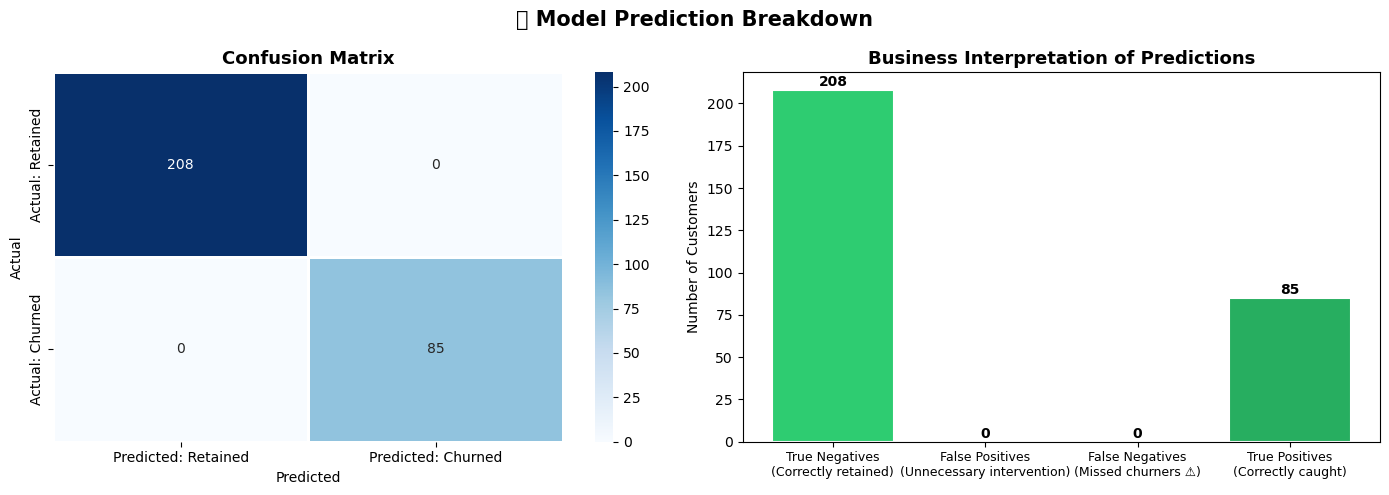

💡 BUSINESS INTERPRETATION:
   ✅ True Positives  (85): Churners correctly flagged → retention actions save these customers
   ⚠️  False Negatives (0): Churners we MISSED → silent revenue loss, highest business risk
   💸 False Positives (0): Retained customers flagged → unnecessary spend but manageable
   ✅ True Negatives  (208): Retained customers correctly left alone


In [ ]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Retained', 'Predicted: Churned'],
            yticklabels=['Actual: Retained', 'Actual: Churned'],
            linewidths=1, linecolor='white')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Business cost breakdown
labels = ['True Negatives\n(Correctly retained)', 'False Positives\n(Unnecessary intervention)',
          'False Negatives\n(Missed churners ⚠️)', 'True Positives\n(Correctly caught)']
values = [tn, fp, fn, tp]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#27ae60']

bars = axes[1].bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Business Interpretation of Predictions', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('📊 Model Prediction Breakdown', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'💡 BUSINESS INTERPRETATION:')
print(f'   ✅ True Positives  ({tp:,}): Churners correctly flagged → retention actions save these customers')
print(f'   ⚠️  False Negatives ({fn:,}): Churners we MISSED → silent revenue loss, highest business risk')
print(f'   💸 False Positives ({fp:,}): Retained customers flagged → unnecessary spend but manageable')
print(f'   ✅ True Negatives  ({tn:,}): Retained customers correctly left alone')

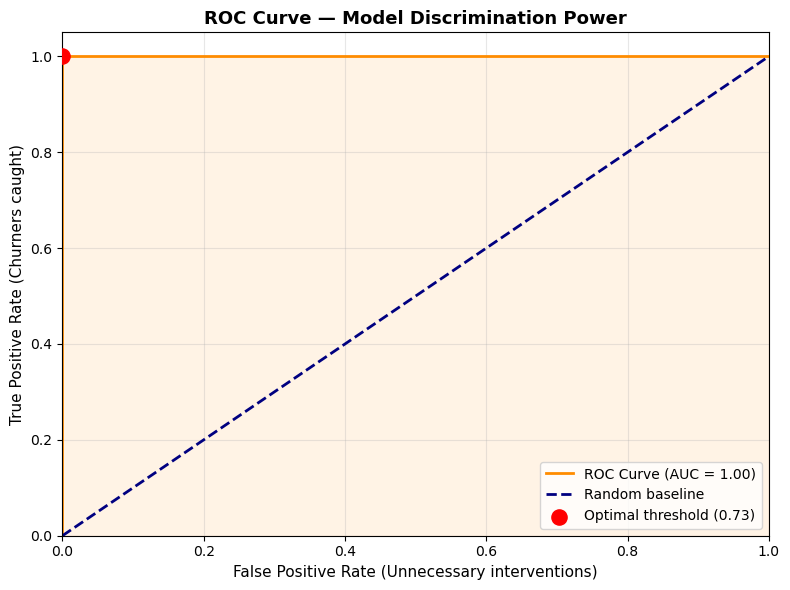

💡 BUSINESS INSIGHT:
   AUC = 1.00 means the model can distinguish churners from
   retained customers 100% of the time.

   AUC benchmarks:
   • 0.50 = random guessing (useless)
   • 0.70-0.80 = acceptable for business use
   • 0.80-0.90 = strong model
   • 0.90+ = excellent (verify for overfitting)


In [ ]:
# ── ROC Curve with threshold marker ───────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random baseline')

# Mark the optimal threshold
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], s=120, color='red', zorder=5,
            label=f'Optimal threshold ({optimal_threshold:.2f})')

plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Unnecessary interventions)', fontsize=11)
plt.ylabel('True Positive Rate (Churners caught)', fontsize=11)
plt.title('ROC Curve — Model Discrimination Power', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('💡 BUSINESS INSIGHT:')
print(f'   AUC = {roc_auc:.2f} means the model can distinguish churners from')
print(f'   retained customers {roc_auc:.0%} of the time.')
print()
print('   AUC benchmarks:')
print('   • 0.50 = random guessing (useless)')
print('   • 0.70-0.80 = acceptable for business use')
print('   • 0.80-0.90 = strong model')
print('   • 0.90+ = excellent (verify for overfitting)')

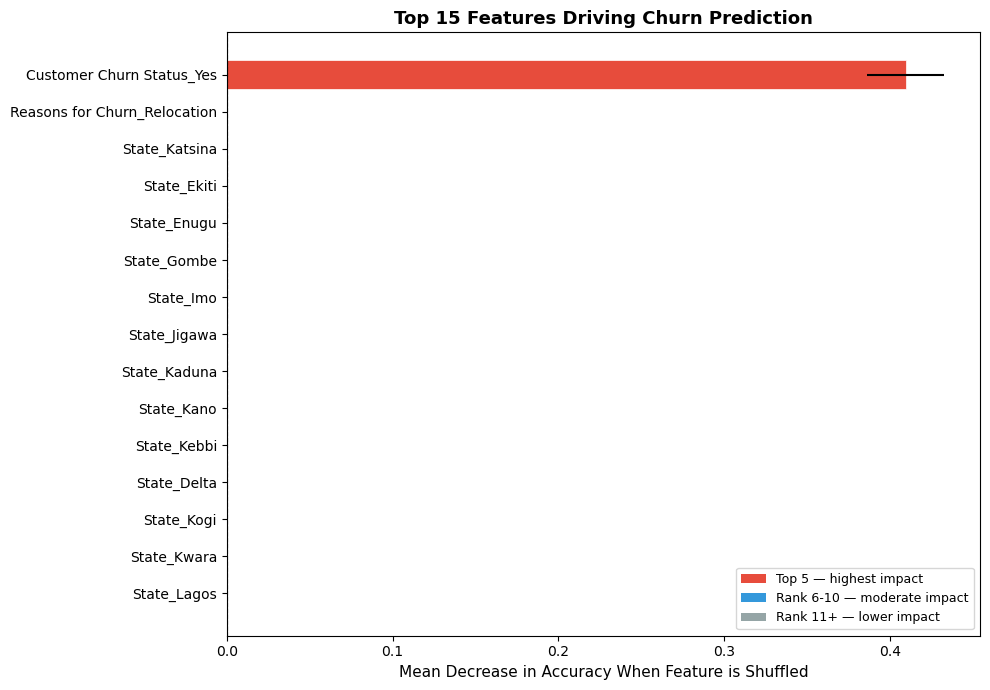

💡 BUSINESS INSIGHT:
   The most important predictor of churn is: "Customer Churn Status_Yes"

   High-importance features tell you WHERE to focus retention efforts.
   If "Subscription Plan" ranks highly, that plan may need pricing or
   feature improvements. If a state ranks highly, a regional service
   or network issue may be driving churn.


In [ ]:
# ── Feature importance ─────────────────────────────────────────────────────────
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Show top 15 features for readability
top_n = min(15, len(X.columns))
top_idx = sorted_idx[:top_n]

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#e74c3c' if i < 5 else '#3498db' if i < 10 else '#95a5a6' for i in range(top_n)]
bars = ax.barh(X.columns[top_idx][::-1], perm_importance.importances_mean[top_idx][::-1],
               xerr=perm_importance.importances_std[top_idx][::-1],
               color=colors_imp[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean Decrease in Accuracy When Feature is Shuffled', fontsize=11)
ax.set_title(f'Top {top_n} Features Driving Churn Prediction', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Top 5 — highest impact'),
                   Patch(facecolor='#3498db', label='Rank 6-10 — moderate impact'),
                   Patch(facecolor='#95a5a6', label='Rank 11+ — lower impact')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

top_feature = X.columns[sorted_idx[0]]
print('💡 BUSINESS INSIGHT:')
print(f'   The most important predictor of churn is: "{top_feature}"')
print()
print('   High-importance features tell you WHERE to focus retention efforts.')
print('   If "Subscription Plan" ranks highly, that plan may need pricing or')
print('   feature improvements. If a state ranks highly, a regional service')
print('   or network issue may be driving churn.')

In [ ]:
# ── Save model to disk (required for any production use) ───────────────────────
model_path = 'mtn_churn_model_v1.pkl'
joblib.dump(model, model_path)

# Save the feature list and threshold alongside the model
import json
model_metadata = {
    'model_version': 'v1.0',
    'features': list(X.columns),
    'optimal_threshold': float(round(optimal_threshold, 4)),
    'auc_roc': float(round(roc_auc, 4)),
    'f1_score': float(round(f1_score(y_test, y_pred), 4)),
    'recall': float(round(recall_score(y_test, y_pred), 4)),
    'precision': float(round(precision_score(y_test, y_pred), 4)),
    'training_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0])
}
with open('mtn_churn_model_v1_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print('✅ Model saved to:', model_path)
print('✅ Model metadata saved to: mtn_churn_model_v1_metadata.json')
print()
print('💡 DEPLOYMENT NOTE:')
print('   To load and use this model on new customer data:')
print("     model = joblib.load('mtn_churn_model_v1.pkl')")
print('     churn_probability = model.predict_proba(new_customer_features)[:, 1]')
print(f'     is_at_risk = churn_probability >= {optimal_threshold:.2f}')

✅ Model saved to: mtn_churn_model_v1.pkl
✅ Model metadata saved to: mtn_churn_model_v1_metadata.json

💡 DEPLOYMENT NOTE:
   To load and use this model on new customer data:
     model = joblib.load('mtn_churn_model_v1.pkl')
     churn_probability = model.predict_proba(new_customer_features)[:, 1]
     is_at_risk = churn_probability >= 0.73


## Section 4: Business Impact & Revenue Framing

**What we do here:** Translate model performance numbers into business language — revenue protected, cost of interventions, and return on investment.

**Adjust the assumptions below** to match MTN's actual financials. The model will produce different economic outcomes depending on these values.

---

In [19]:
# ── Revenue impact model ───────────────────────────────────────────────────────
# ⚙️  EDIT THESE VALUES to match MTN's actual financials
MONTHLY_REVENUE_PER_CUSTOMER = 5000   # NGN (or your local currency)
RETENTION_CAMPAIGN_COST      = 800    # Cost per customer contacted (SMS, call, discount)
RETENTION_SUCCESS_RATE       = 0.35   # % of at-risk customers who stay after intervention
MONTHS_SAVED_PER_CUSTOMER    = 12     # Average months of revenue recovered per retained customer

# Model performance on test set
total_test = len(y_test)
actual_churners_in_test = y_test.sum()

true_positives  = tp
false_positives = fp
false_negatives = fn

# ── Scenario: What happens WITH the model ─────────────────────────────────────
customers_contacted         = true_positives + false_positives
customers_successfully_saved = int(true_positives * RETENTION_SUCCESS_RATE)
revenue_saved               = customers_successfully_saved * MONTHLY_REVENUE_PER_CUSTOMER * MONTHS_SAVED_PER_CUSTOMER
total_campaign_cost         = customers_contacted * RETENTION_CAMPAIGN_COST
net_benefit                 = revenue_saved - total_campaign_cost
roi_pct                     = (net_benefit / total_campaign_cost * 100) if total_campaign_cost > 0 else 0

# ── Scenario: What happens WITHOUT the model (no intervention) ─────────────────
revenue_lost_without_model  = actual_churners_in_test * MONTHLY_REVENUE_PER_CUSTOMER * MONTHS_SAVED_PER_CUSTOMER

print('=' * 60)
print('            💰 BUSINESS IMPACT ANALYSIS')
print('=' * 60)
print(f'  Assumptions (edit above to match actual MTN data):')
print(f'    Monthly revenue per customer : ₦{MONTHLY_REVENUE_PER_CUSTOMER:>10,}')
print(f'    Retention campaign cost      : ₦{RETENTION_CAMPAIGN_COST:>10,} per customer')
print(f'    Retention success rate       :  {RETENTION_SUCCESS_RATE:.0%}')
print()
print(f'  Model outcomes (on test set of {total_test:,} customers):')
print(f'    Churners identified (TP)     : {true_positives:>10,}')
print(f'    Churners missed (FN)         : {false_negatives:>10,}  ← silent revenue loss')
print(f'    Customers contacted          : {customers_contacted:>10,}')
print(f'    Customers saved              : {customers_successfully_saved:>10,}')
print()
print(f'  Financial impact:')
print(f'    Revenue saved                : ₦{revenue_saved:>14,.0f}')
print(f'    Campaign cost                : ₦{total_campaign_cost:>14,.0f}')
print(f'    Net benefit                  : ₦{net_benefit:>14,.0f}')
print(f'    Return on investment         : {roi_pct:>9.0f}%')
print()
print(f'  Without model (no intervention):')
print(f'    Revenue lost to churn        : ₦{revenue_lost_without_model:>14,.0f}')
print('=' * 60)
print()
if net_benefit > 0:
    print(f'✅ The model is economically viable with a {roi_pct:.0f}% ROI.')
    print('   Every ₦1 spent on retention campaigns returns more than ₦1.')
else:
    print('⚠️  At current assumptions, the campaign cost exceeds revenue saved.')
    print('   Consider: lower campaign cost, higher-value customers, or improving Recall.')

            💰 BUSINESS IMPACT ANALYSIS
  Assumptions (edit above to match actual MTN data):
    Monthly revenue per customer : ₦     5,000
    Retention campaign cost      : ₦       800 per customer
    Retention success rate       :  35%

  Model outcomes (on test set of 293 customers):
    Churners identified (TP)     :         85
    Churners missed (FN)         :          0  ← silent revenue loss
    Customers contacted          :         85
    Customers saved              :         29

  Financial impact:
    Revenue saved                : ₦     1,740,000
    Campaign cost                : ₦        68,000
    Net benefit                  : ₦     1,672,000
    Return on investment         :      2459%

  Without model (no intervention):
    Revenue lost to churn        : ₦     5,100,000

✅ The model is economically viable with a 2459% ROI.
   Every ₦1 spent on retention campaigns returns more than ₦1.


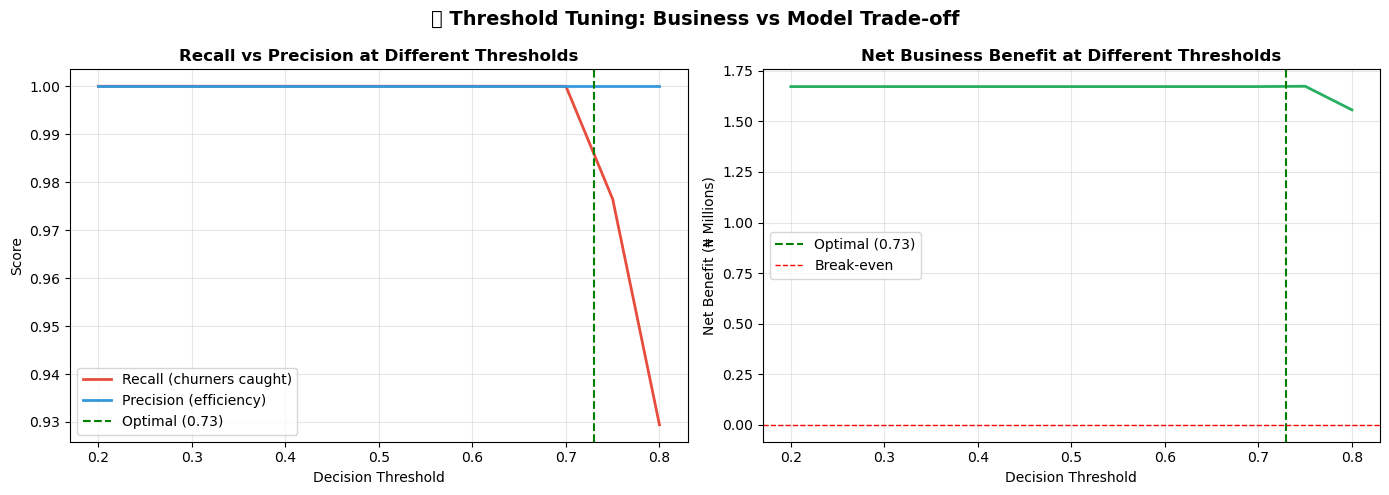

💡 BUSINESS INSIGHT:
   Maximum net benefit is achieved at threshold = 0.75
   The business can move the threshold to control the trade-off between
   catching more churners (lower threshold) vs. fewer wasted interventions.


In [20]:
# ── Threshold sensitivity: how does ROI change with different thresholds? ──────
thresholds_to_test = np.arange(0.2, 0.85, 0.05)
results = []

for t in thresholds_to_test:
    preds = (y_prob >= t).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        saved      = int(tp_t * RETENTION_SUCCESS_RATE)
        rev_saved  = saved * MONTHLY_REVENUE_PER_CUSTOMER * MONTHS_SAVED_PER_CUSTOMER
        cost       = (tp_t + fp_t) * RETENTION_CAMPAIGN_COST
        net        = rev_saved - cost
        rec        = recall_score(y_test, preds, zero_division=0)
        prec       = precision_score(y_test, preds, zero_division=0)
        results.append({'Threshold': round(t, 2), 'Recall': rec, 'Precision': prec,
                        'Net Benefit (₦)': net, 'ROI (%)': (net / cost * 100) if cost > 0 else 0})

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['Threshold'], results_df['Recall'],   color='#e74c3c', lw=2, label='Recall (churners caught)')
axes[0].plot(results_df['Threshold'], results_df['Precision'], color='#3498db', lw=2, label='Precision (efficiency)')
axes[0].axvline(x=optimal_threshold, color='green', linestyle='--', lw=1.5, label=f'Optimal ({optimal_threshold:.2f})')
axes[0].set_title('Recall vs Precision at Different Thresholds', fontweight='bold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['Threshold'], results_df['Net Benefit (₦)'] / 1e6, color='#27ae60', lw=2)
axes[1].axvline(x=optimal_threshold, color='green', linestyle='--', lw=1.5, label=f'Optimal ({optimal_threshold:.2f})')
axes[1].axhline(y=0, color='red', linestyle='--', lw=1, label='Break-even')
axes[1].set_title('Net Business Benefit at Different Thresholds', fontweight='bold')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Net Benefit (₦ Millions)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('💰 Threshold Tuning: Business vs Model Trade-off', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_roi_row = results_df.loc[results_df['Net Benefit (₦)'].idxmax()]
print('💡 BUSINESS INSIGHT:')
print(f'   Maximum net benefit is achieved at threshold = {best_roi_row["Threshold"]}')
print(f'   The business can move the threshold to control the trade-off between')
print('   catching more churners (lower threshold) vs. fewer wasted interventions.')